## EDA of Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns


In [4]:
df=pd.read_csv('datasets/kidney_disease.csv')

In [5]:
df.shape

(400, 26)

In [6]:
df.columns

Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='str')

In [7]:
df.isnull().sum()

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [8]:
df.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    str    
 7   pc              335 non-null    str    
 8   pcc             396 non-null    str    
 9   ba              396 non-null    str    
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    str    
 17  wc              295 non-null    str    
 18  r

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.head(4)

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd


## Data Cleaning

In [12]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

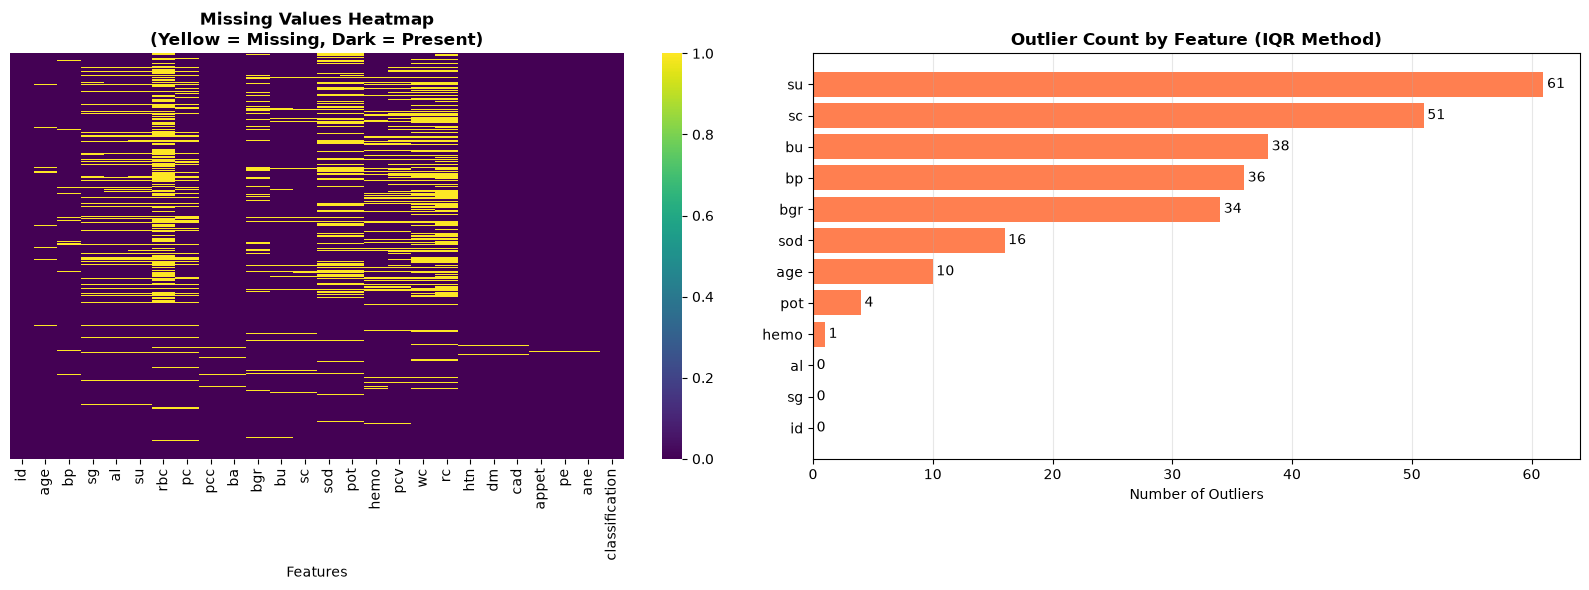


Outlier Summary:
Feature  Outlier_Count
     id              0
     sg              0
     al              0
   hemo              1
    pot              4
    age             10
    sod             16
    bgr             34
     bp             36
     bu             38
     sc             51
     su             61


In [13]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 10.1 Missing value heatmap
ax1 = axes[0]
missing_data = df.isnull()
sns.heatmap(missing_data, cbar=True, yticklabels=False, cmap='viridis', ax=ax1)
ax1.set_title('Missing Values Heatmap\n(Yellow = Missing, Dark = Present)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Features')

# 10.2 Outlier detection (using IQR method)
ax2 = axes[1]
outlier_counts = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    outlier_counts[col] = len(outliers)

outlier_df = pd.DataFrame(list(outlier_counts.items()), columns=['Feature', 'Outlier_Count'])
outlier_df = outlier_df.sort_values('Outlier_Count', ascending=True)

bars = ax2.barh(outlier_df['Feature'], outlier_df['Outlier_Count'], color='coral')
ax2.set_title('Outlier Count by Feature (IQR Method)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Number of Outliers')
ax2.grid(axis='x', alpha=0.3)

# Add value labels
for bar, val in zip(bars, outlier_df['Outlier_Count']):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height()/2, str(val), va='center')

plt.tight_layout()
plt.savefig('eda_step10_missing_outliers.png',
            dpi=150,
            bbox_inches='tight')
plt.show()

print("\nOutlier Summary:")
print(outlier_df.to_string(index=False))


C:\Users\babar\AppData\Local\Temp\ipykernel_17752\2361620115.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Feature', y='Value', data=melted, inner='box', palette='Set3', ax=axes[0])
C:\Users\babar\AppData\Local\Temp\ipykernel_17752\2361620115.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Value', y='Feature', data=melted, palette='pastel', ax=axes[1])


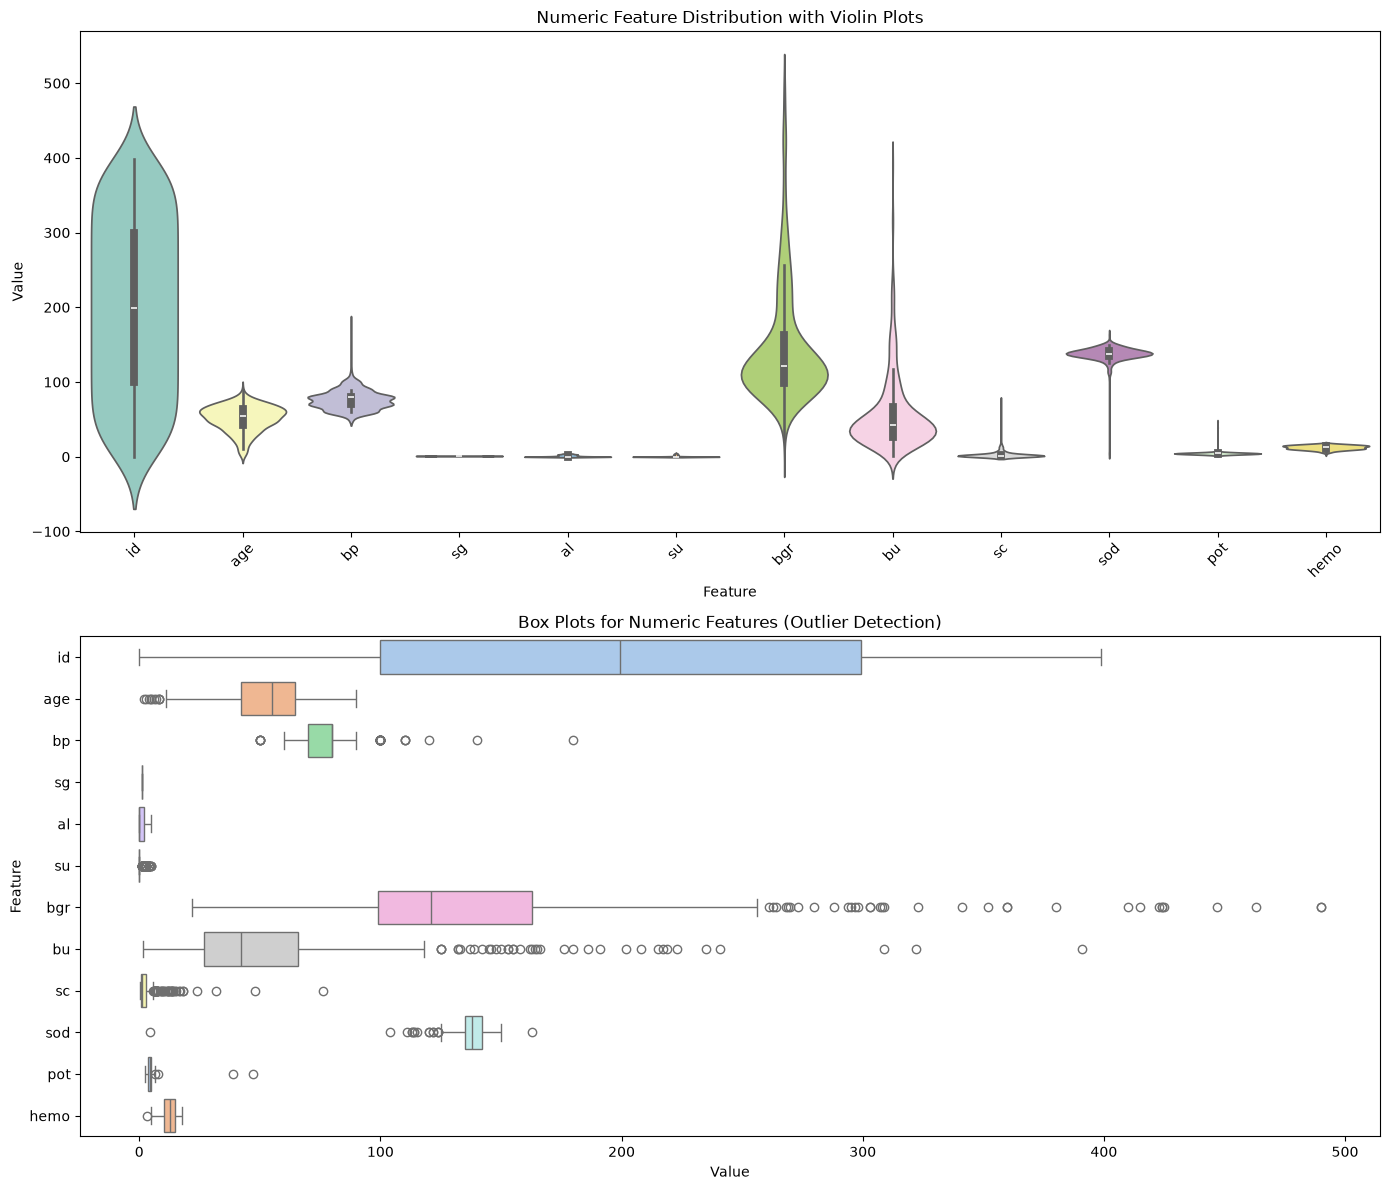

Original rows: 400
Rows after removing numeric outliers: 139


<Figure size 640x480 with 0 Axes>

In [14]:
melted = df[numeric_cols].melt(var_name='Feature', value_name='Value')

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

sns.violinplot(x='Feature', y='Value', data=melted, inner='box', palette='Set3', ax=axes[0])
axes[0].set_title('Numeric Feature Distribution with Violin Plots')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(x='Value', y='Feature', data=melted, palette='pastel', ax=axes[1])
axes[1].set_title('Box Plots for Numeric Features (Outlier Detection)')

plt.tight_layout()
plt.show()

df_clean = df.copy()
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    plt.savefig('eda_step11_missing_outliers.png',
            dpi=150,
            bbox_inches='tight')

print(f"Original rows: {len(df)}")
print(f"Rows after removing numeric outliers: {len(df_clean)}")

df = df_clean

In [15]:
df['pcv'].value_counts()

pcv
52    16
48    14
41    14
44    12
45    11
43    10
50    10
46     8
42     7
40     7
49     4
51     4
54     4
39     3
47     3
53     3
32     2
37     2
33     1
36     1
35     1
31     1
Name: count, dtype: int64

In [16]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
5,5,60.0,90.0,1.015,3.0,0.0,NaN,NaN,notpresent,notpresent,...,39,7800,4.4,yes,yes,no,good,yes,no,ckd
36,36,76.0,70.0,1.015,1.0,0.0,normal,normal,notpresent,notpresent,...,32,NaN,NaN,yes,no,no,good,no,no,ckd
46,46,48.0,70.0,1.015,0.0,0.0,NaN,normal,notpresent,notpresent,...,37,6400,4.7,no,yes,no,good,no,no,ckd
62,62,15.0,60.0,1.020,3.0,0.0,NaN,normal,notpresent,notpresent,...,33,7700,3.8,yes,yes,no,good,no,no,ckd
94,94,65.0,70.0,1.010,0.0,0.0,NaN,normal,notpresent,notpresent,...,36,11900,3.9,no,yes,no,good,no,no,ckd


In [17]:
non_numeric_cols = df.select_dtypes(exclude='number').columns.tolist()

for col in non_numeric_cols:
    converted = pd.to_numeric(df[col], errors='coerce')
    if converted.notna().all():
        df[col] = converted
    else:
        df[col] = df[col].astype('category').cat.codes.replace(-1, np.nan)

df.dtypes

id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc               float64
pc                float64
pcc               float64
ba                float64
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv               float64
wc                float64
rc                float64
htn               float64
dm                float64
cad               float64
appet             float64
pe                float64
ane               float64
classification       int8
dtype: object

In [18]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
5,5,60.0,90.0,1.015,3.0,0.0,NaN,NaN,0.0,0.0,...,6.0,35.0,3.0,1.0,1.0,0.0,0.0,1.0,0.0,0
36,36,76.0,70.0,1.015,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0
46,46,48.0,70.0,1.015,0.0,0.0,NaN,1.0,0.0,0.0,...,5.0,22.0,6.0,0.0,1.0,0.0,0.0,0.0,0.0,0
62,62,15.0,60.0,1.020,3.0,0.0,NaN,1.0,0.0,0.0,...,2.0,34.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0
94,94,65.0,70.0,1.010,0.0,0.0,NaN,1.0,0.0,0.0,...,4.0,6.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0


In [19]:
missing_cols = df.columns[df.isnull().any()].tolist()
missing_cols

['rbc',
 'pc',
 'pcc',
 'ba',
 'pcv',
 'wc',
 'rc',
 'htn',
 'dm',
 'cad',
 'appet',
 'pe',
 'ane']

In [20]:
from sklearn.impute import SimpleImputer

imputer=SimpleImputer(strategy='median')
for i in missing_cols:
    df[i]=imputer.fit_transform(df[[i]])

In [21]:
df.isnull().sum()

id                0
age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64

### EDA Analysis

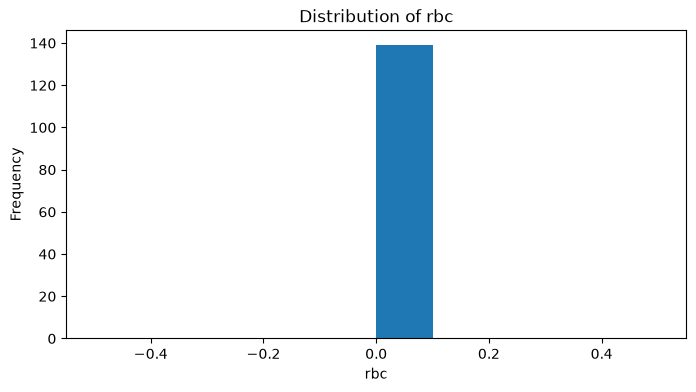

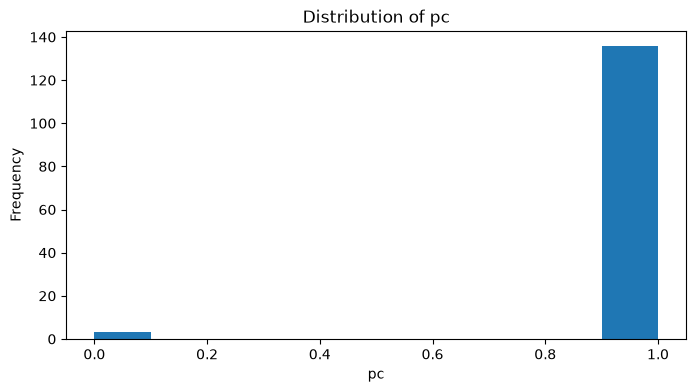

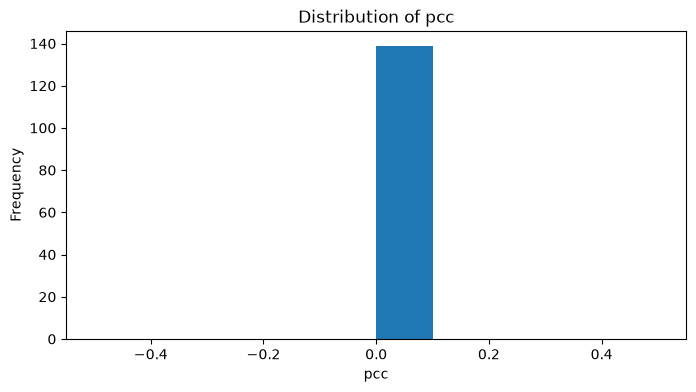

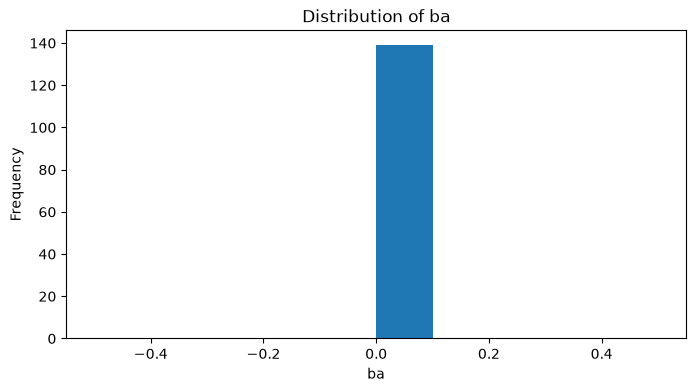

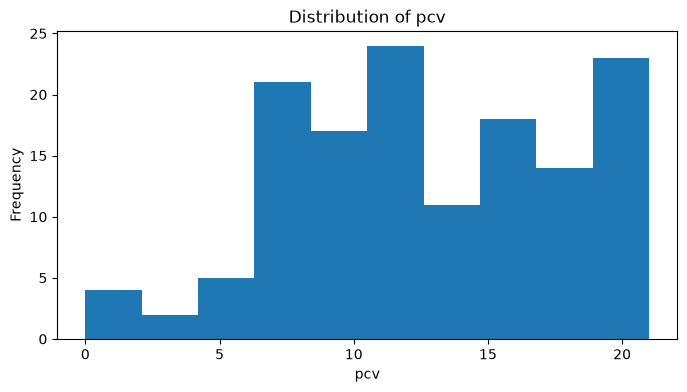

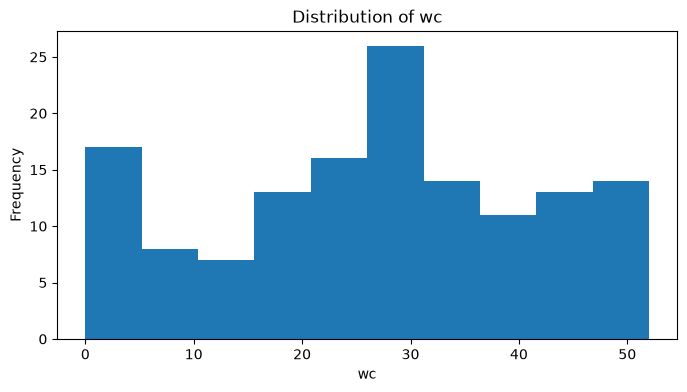

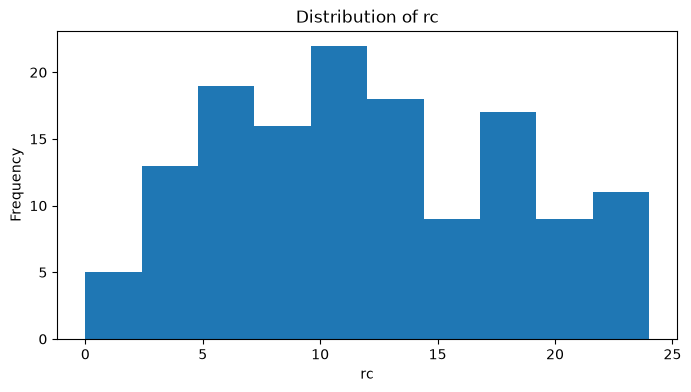

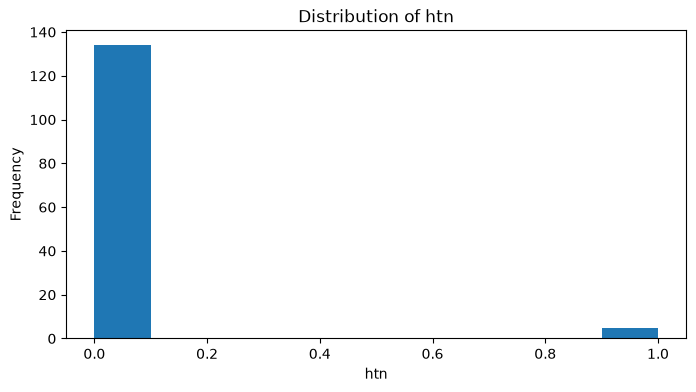

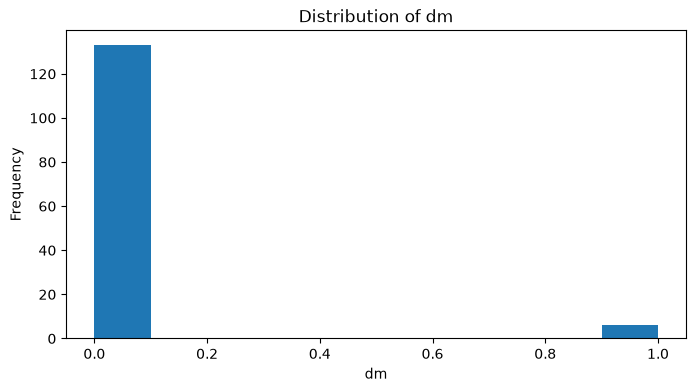

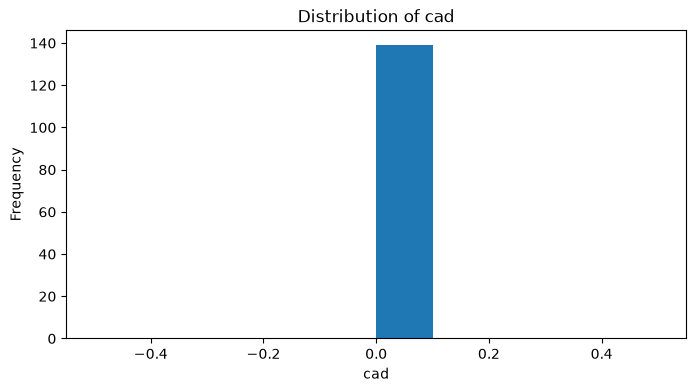

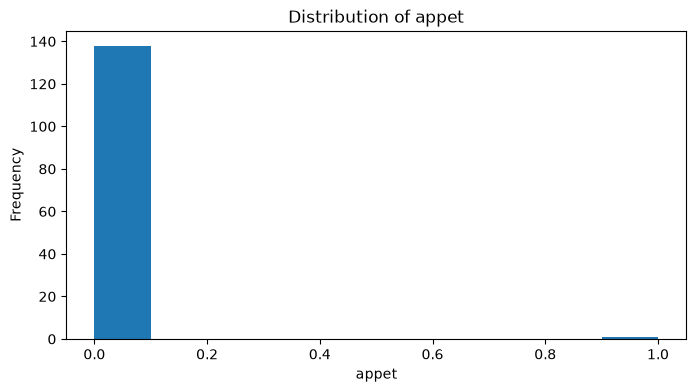

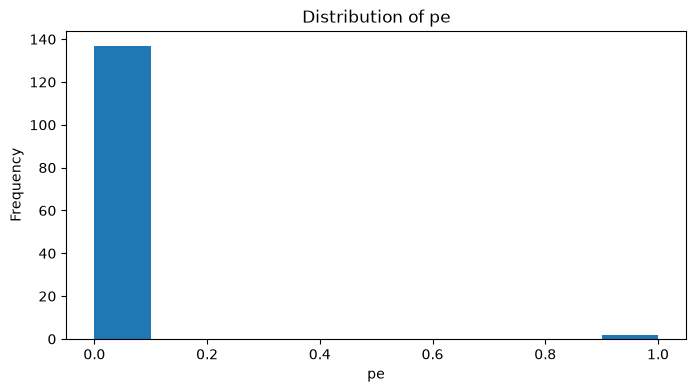

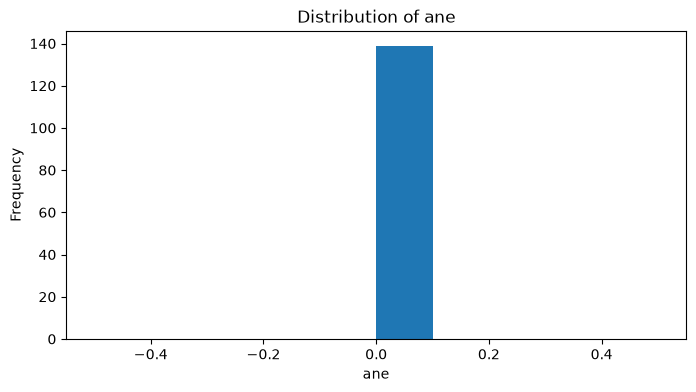

In [22]:
for i in missing_cols:
    plt.figure(figsize=(8,4))
    plt.hist(df[i].dropna())
    plt.xlabel(i)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {i}')
    plt.show()

In [23]:
columns_list = df.columns.tolist()
columns_list

['id',
 'age',
 'bp',
 'sg',
 'al',
 'su',
 'rbc',
 'pc',
 'pcc',
 'ba',
 'bgr',
 'bu',
 'sc',
 'sod',
 'pot',
 'hemo',
 'pcv',
 'wc',
 'rc',
 'htn',
 'dm',
 'cad',
 'appet',
 'pe',
 'ane',
 'classification']

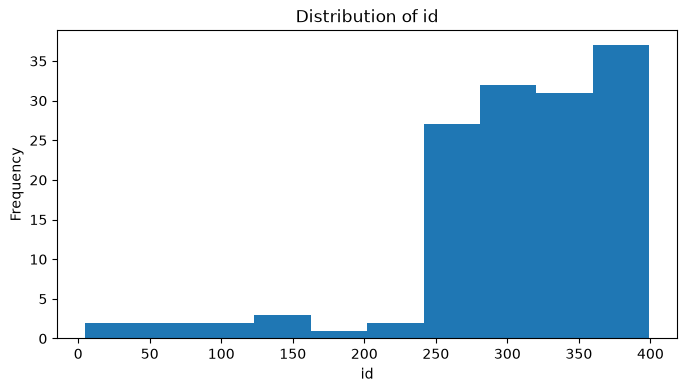

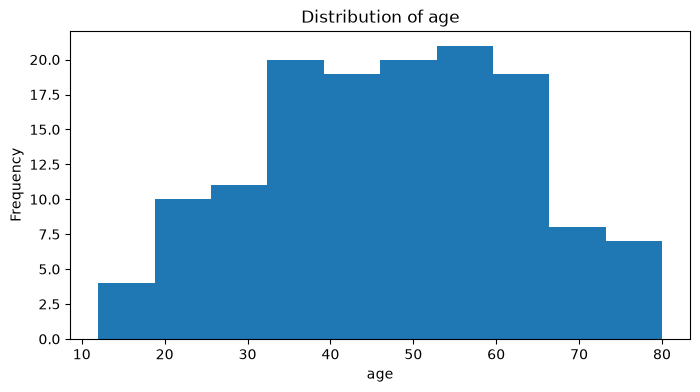

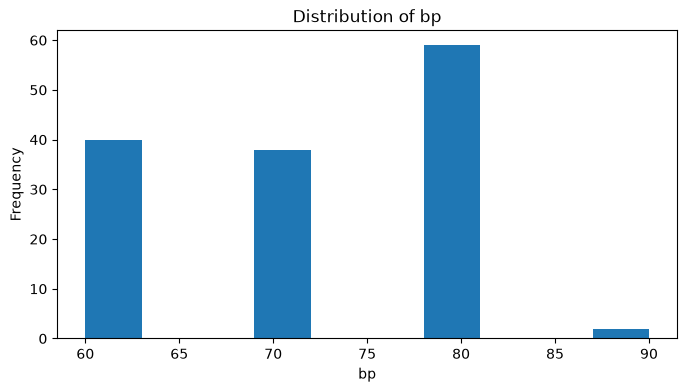

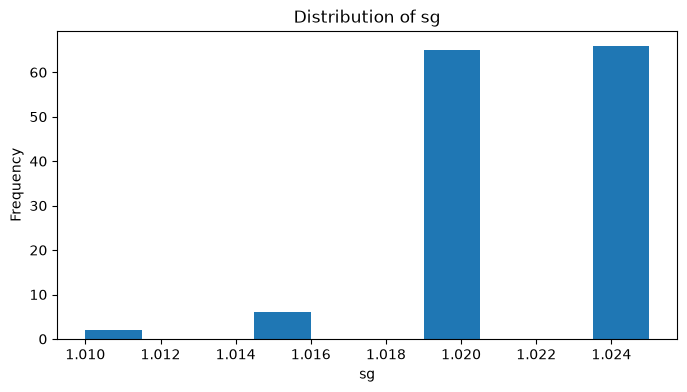

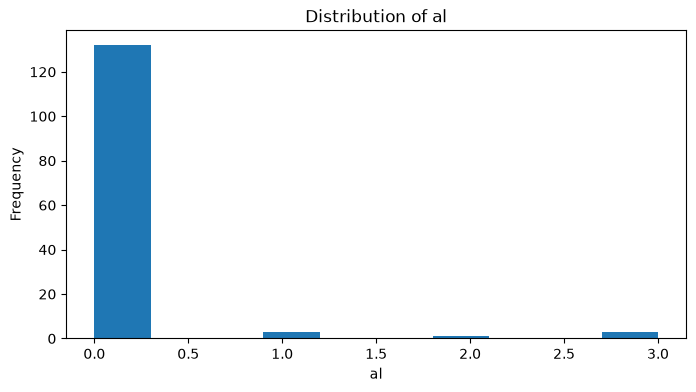

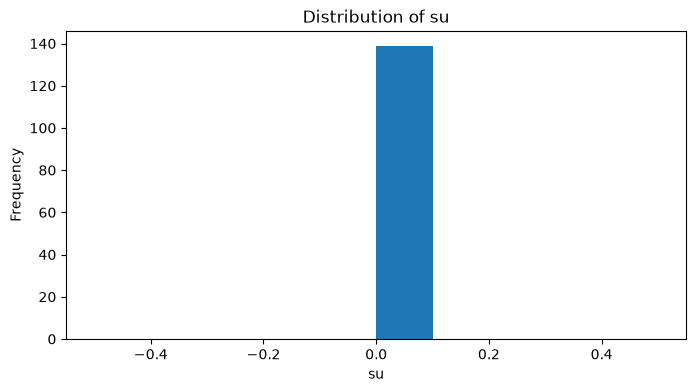

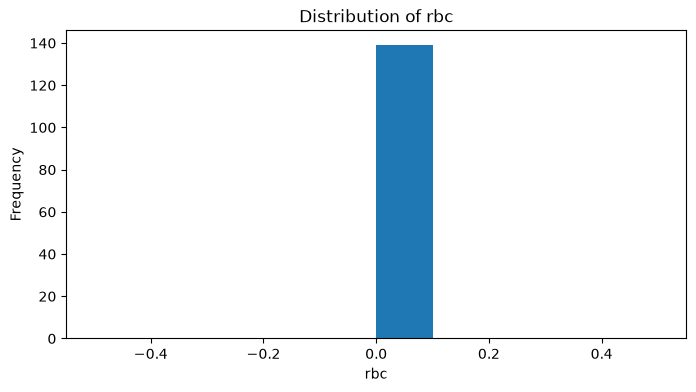

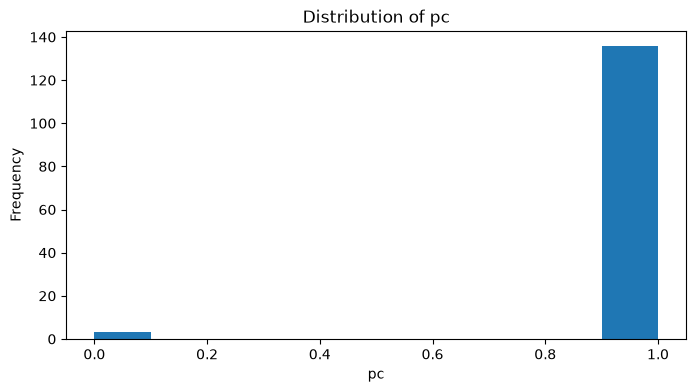

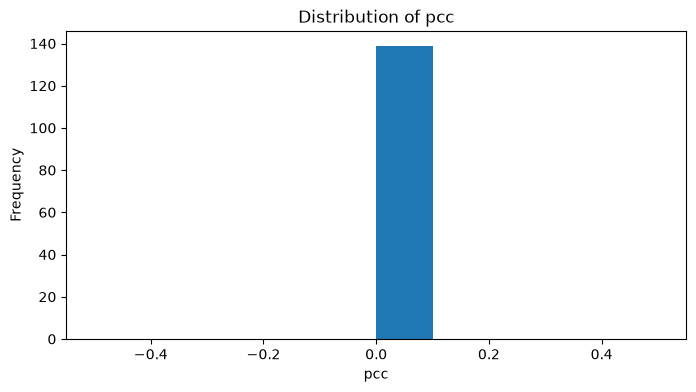

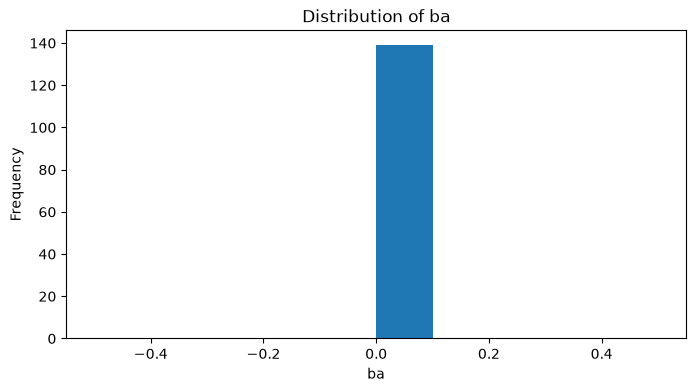

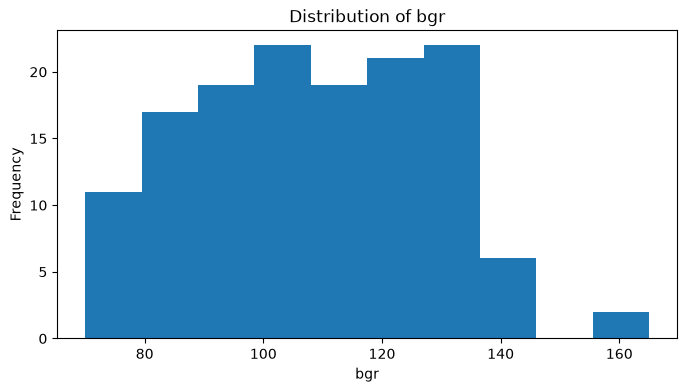

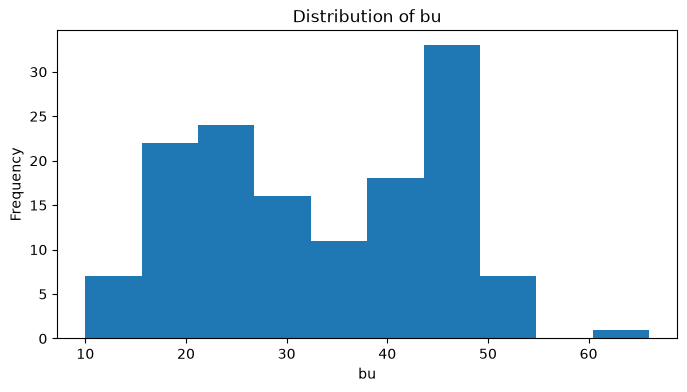

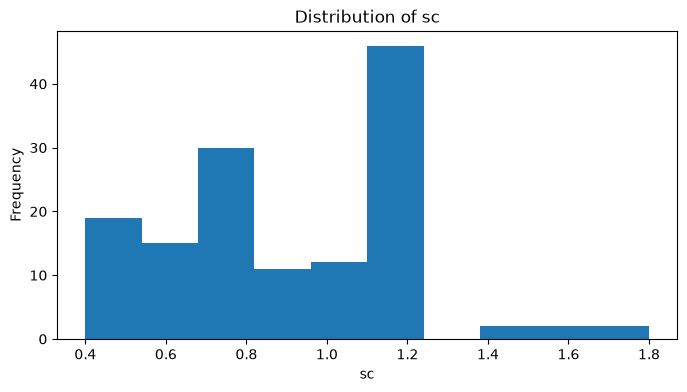

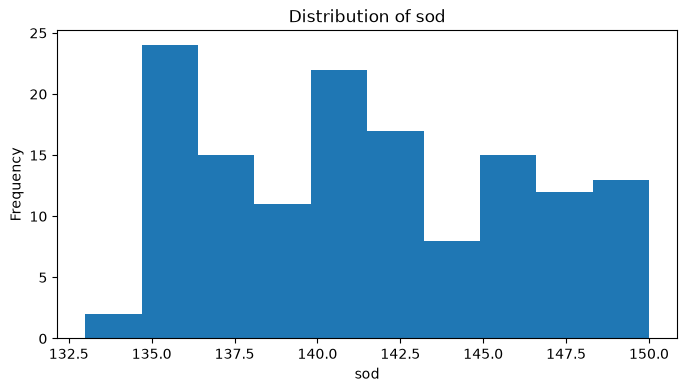

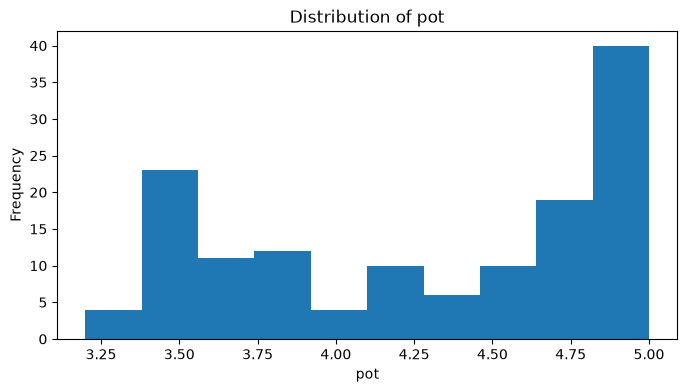

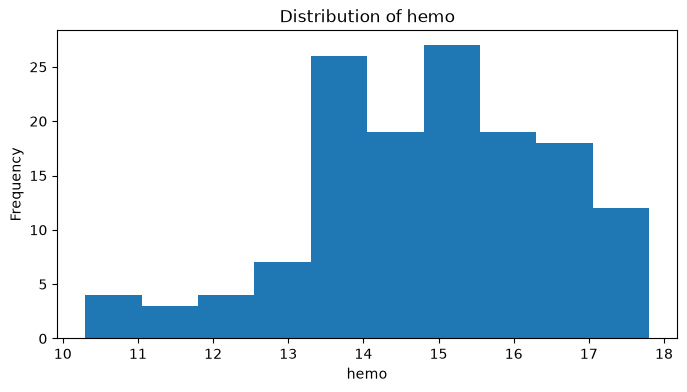

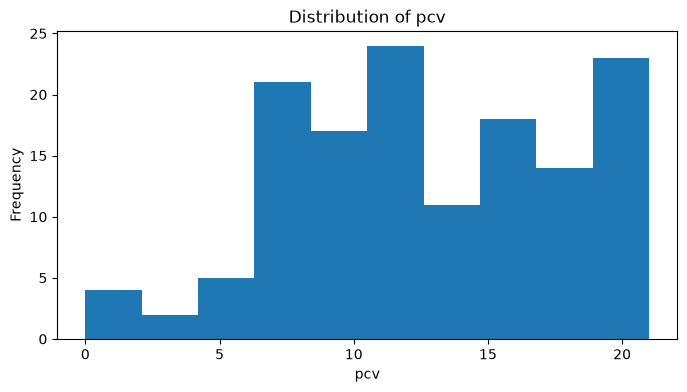

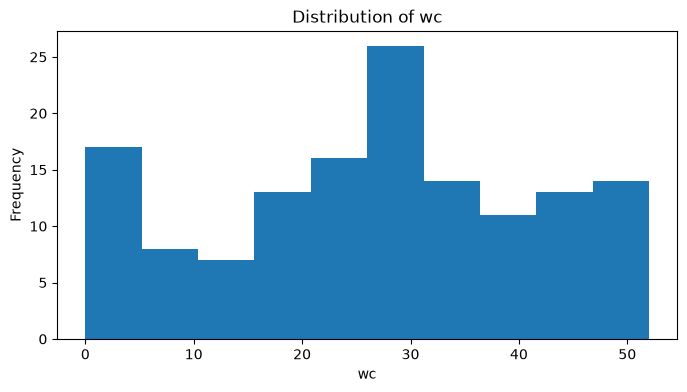

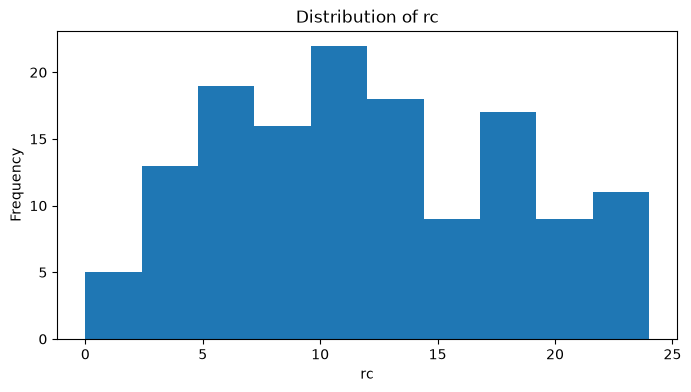

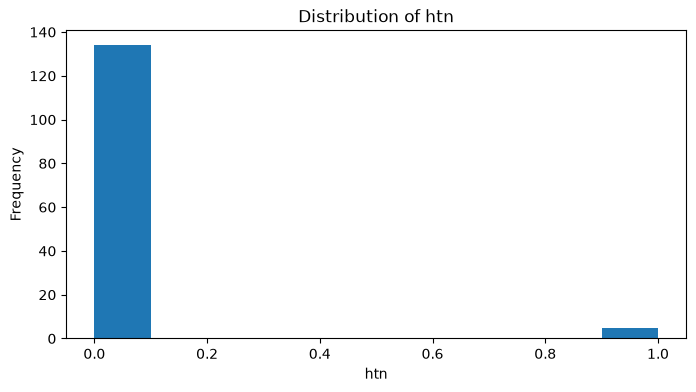

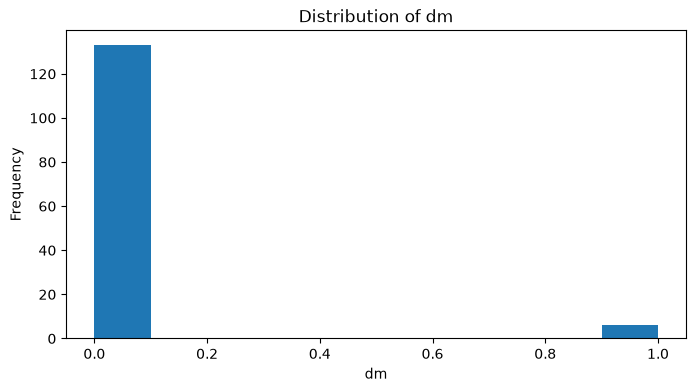

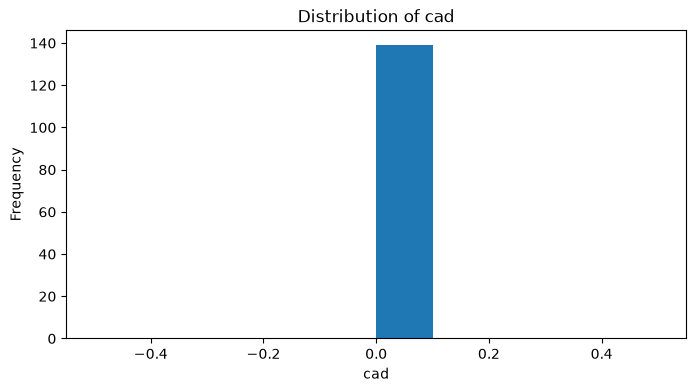

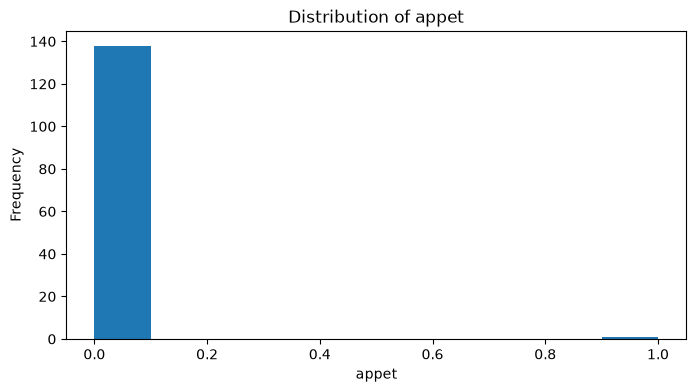

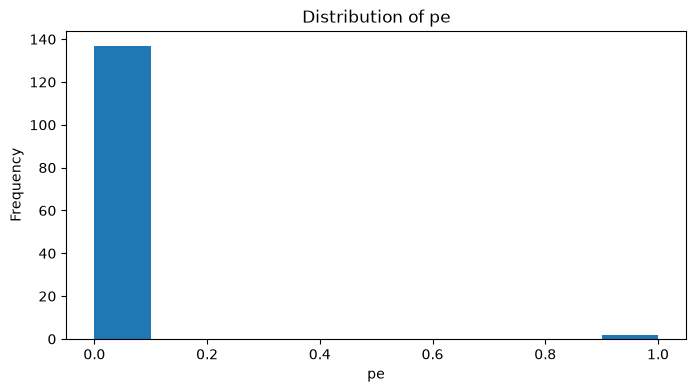

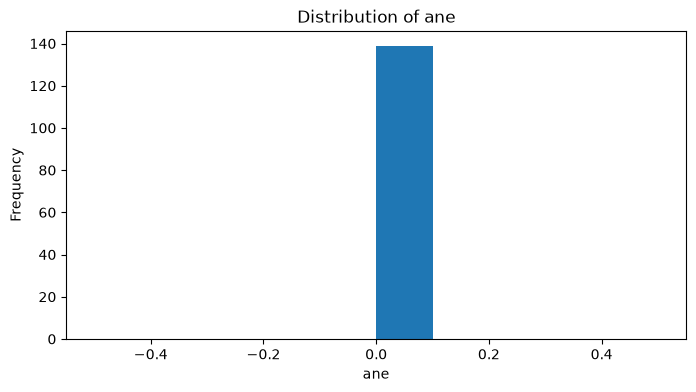

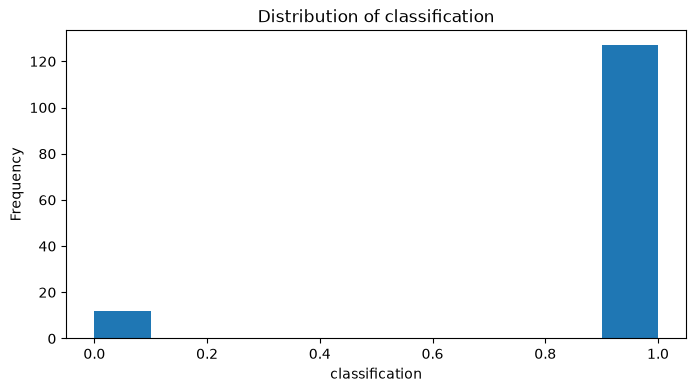

In [24]:
for i in columns_list:
    plt.figure(figsize=(8,4))
    plt.hist(df[i])
    plt.xlabel(i)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {i}')
    plt.show()

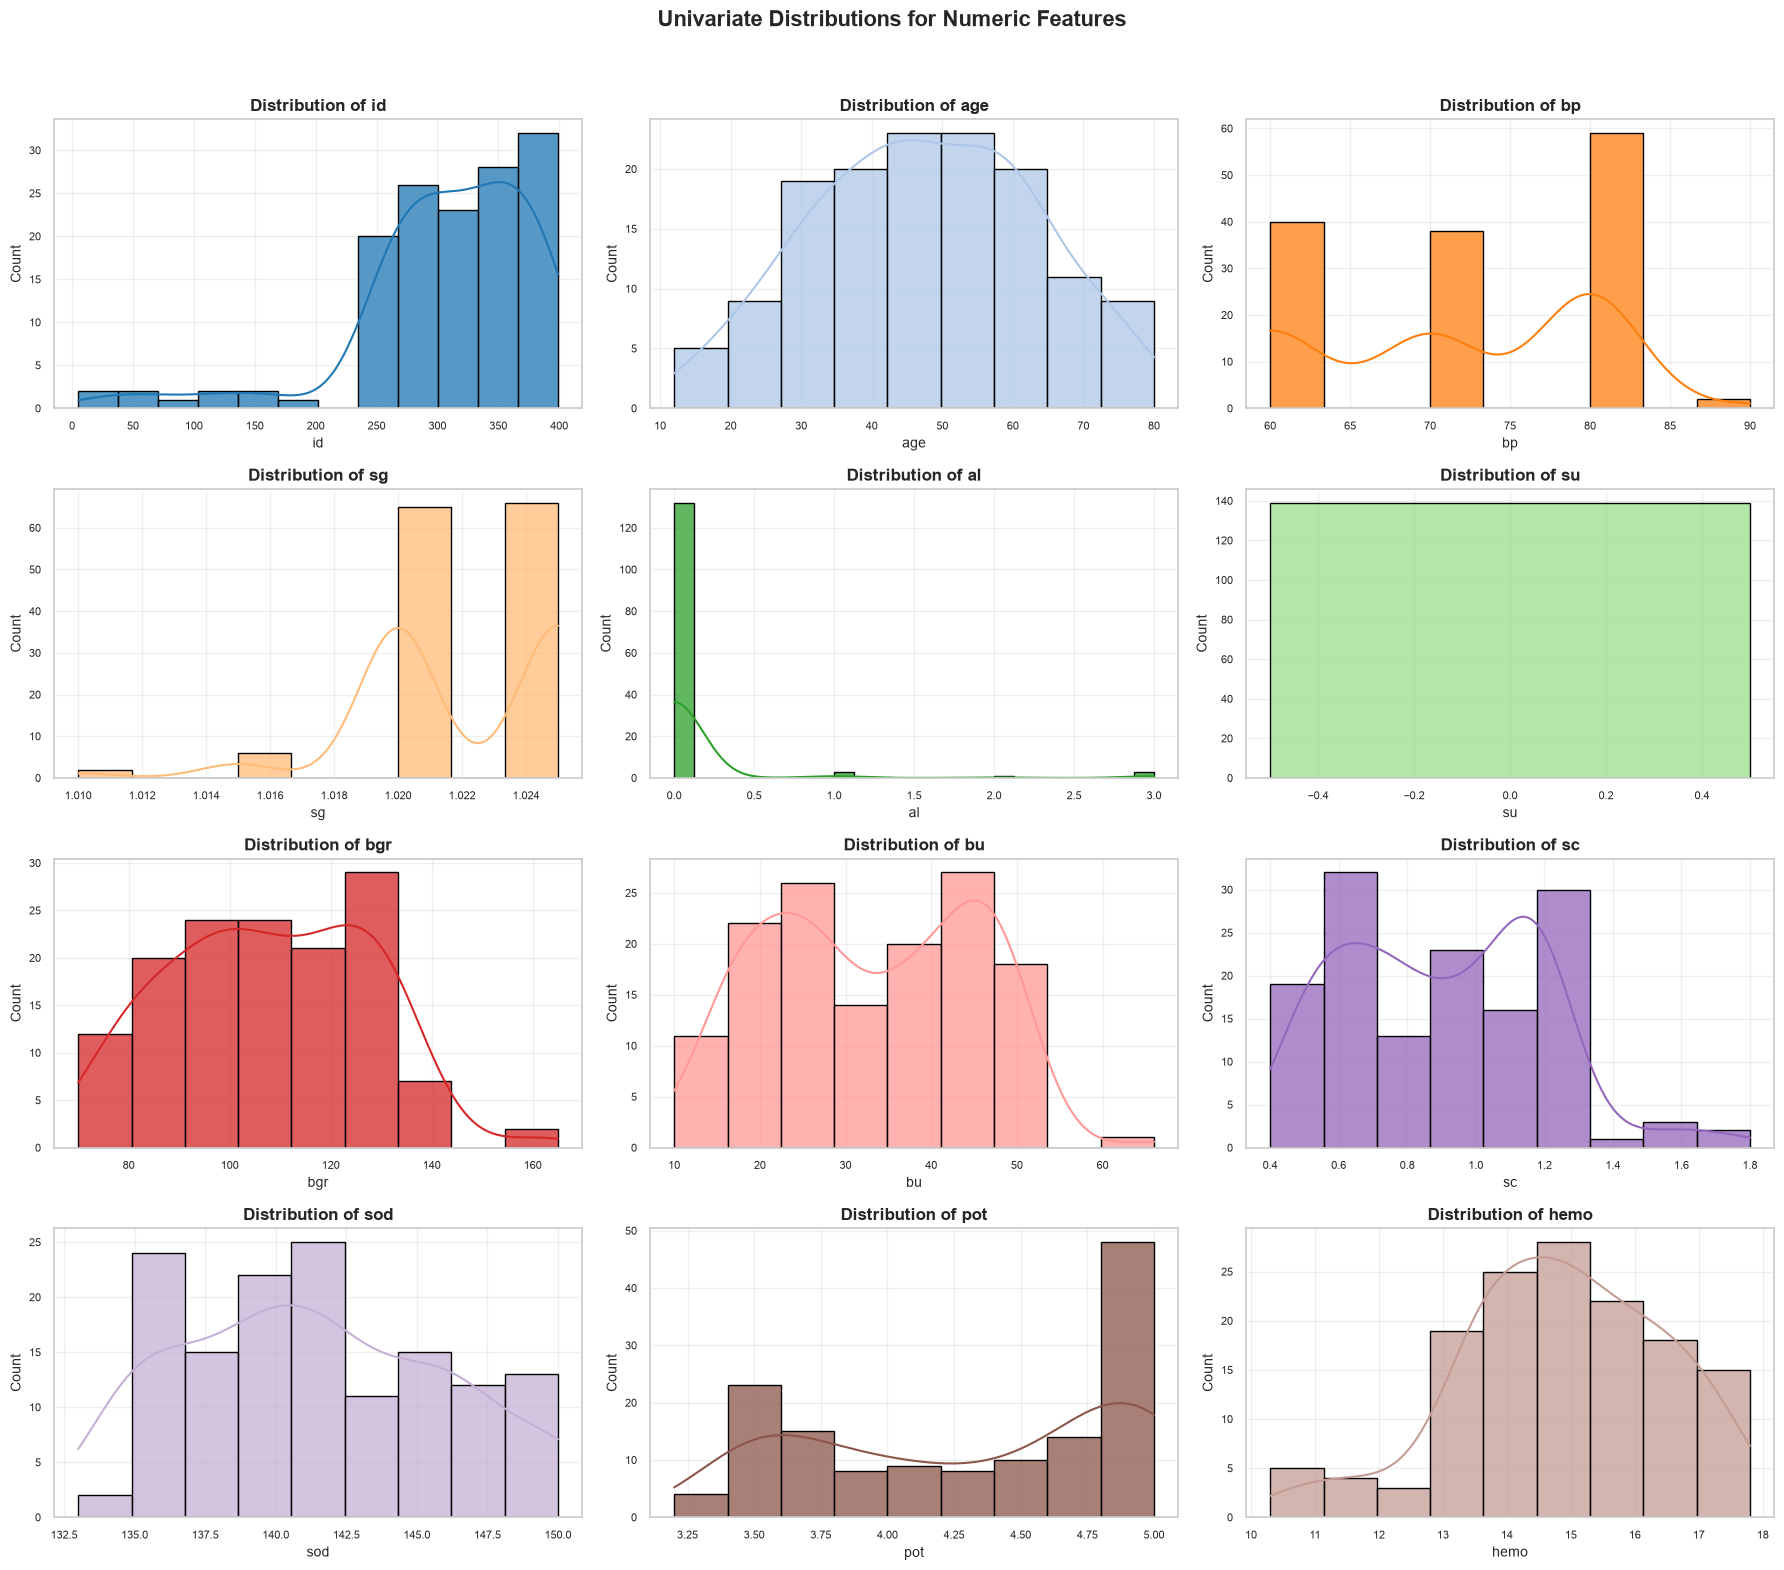

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

palette = sns.color_palette('tab20', len(numeric_cols))

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for col, ax, color in zip(numeric_cols, axes, palette):
    sns.histplot(
        df[col].dropna(),
        kde=True,
        color=color,
        ax=ax,
        edgecolor='black',
        alpha=0.75
    )
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='both', labelsize=8)

# Remove unused subplots
for ax in axes[len(numeric_cols):]:
    fig.delaxes(ax)

fig.suptitle('Univariate Distributions for Numeric Features',
             fontsize=16,
             fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('univariate_numeric_distributions.png',
            dpi=150,
            bbox_inches='tight')
plt.show()

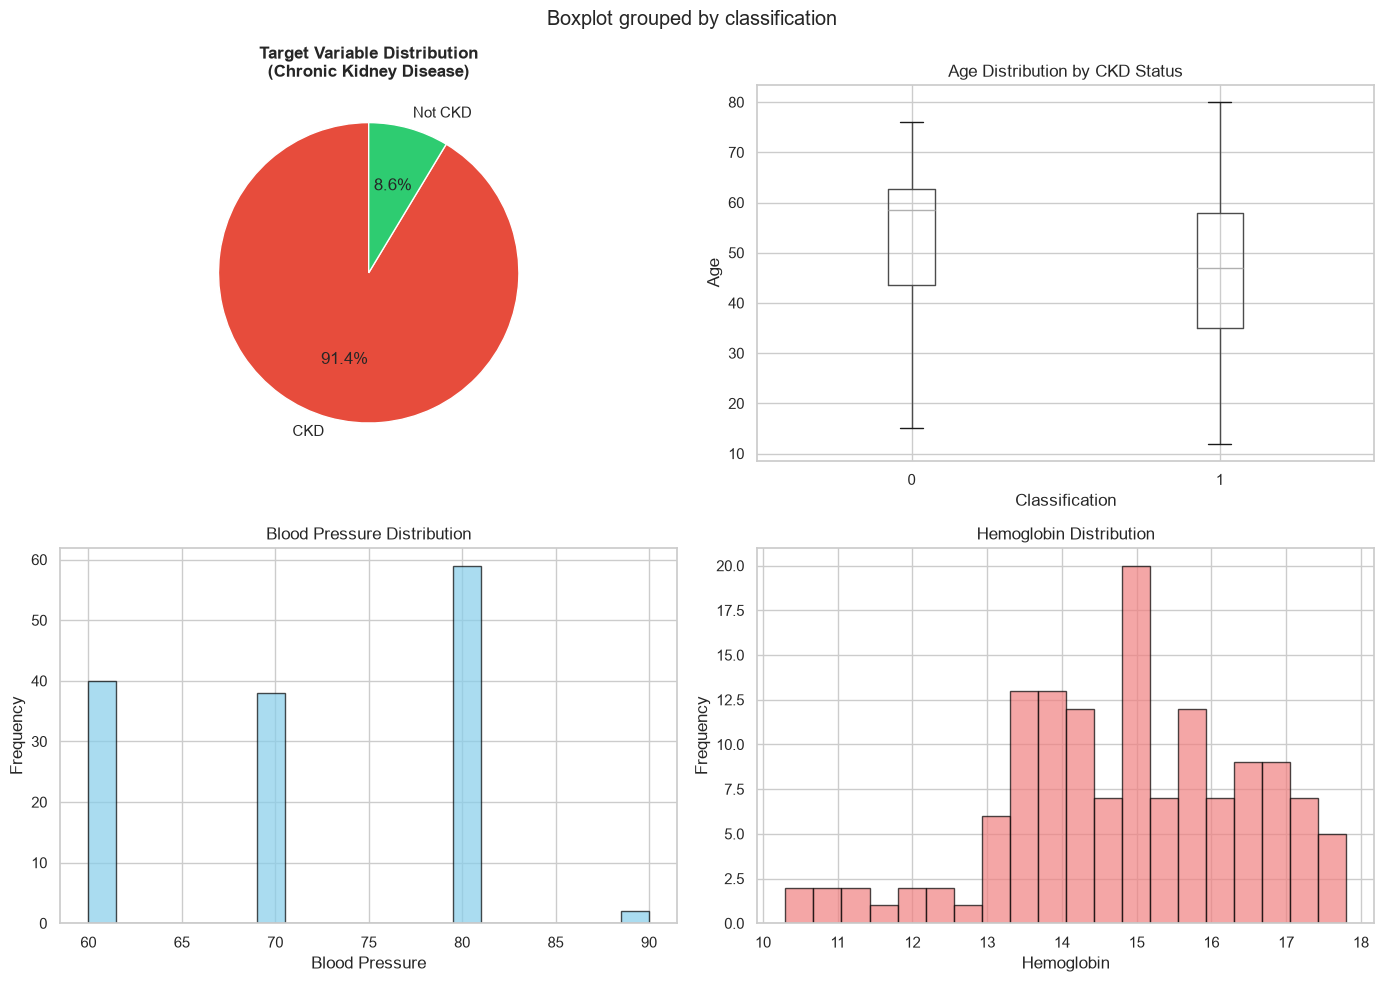

Chart saved successfully in output/eda_step6_distributions.png


In [29]:
import os
os.makedirs('output', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Target variable distribution
ax1 = axes[0, 0]
target_counts = df_clean['classification'].value_counts()
colors = ['#e74c3c', '#2ecc71']
ax1.pie(target_counts,
        labels=['CKD', 'Not CKD'],
        autopct='%1.1f%%',
        colors=colors,
        startangle=90)
ax1.set_title('Target Variable Distribution\n(Chronic Kidney Disease)',
              fontsize=12,
              fontweight='bold')

# Age distribution by class
ax2 = axes[0, 1]
df_clean.boxplot(column='age', by='classification', ax=ax2)
ax2.set_title('Age Distribution by CKD Status')
ax2.set_xlabel('Classification')
ax2.set_ylabel('Age')

# Blood pressure distribution
ax3 = axes[1, 0]
ax3.hist(df_clean['bp'].dropna(),
         bins=20,
         color='skyblue',
         edgecolor='black',
         alpha=0.7)
ax3.set_title('Blood Pressure Distribution')
ax3.set_xlabel('Blood Pressure')
ax3.set_ylabel('Frequency')

# Hemoglobin distribution
ax4 = axes[1, 1]
ax4.hist(df_clean['hemo'].dropna(),
         bins=20,
         color='lightcoral',
         edgecolor='black',
         alpha=0.7)
ax4.set_title('Hemoglobin Distribution')
ax4.set_xlabel('Hemoglobin')
ax4.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('output/eda_step6_distributions.png',
            dpi=150,
            bbox_inches='tight')
plt.show()

print("Chart saved successfully in output/eda_step6_distributions.png")

STEP 8: CATEGORICAL FEATURES VS TARGET


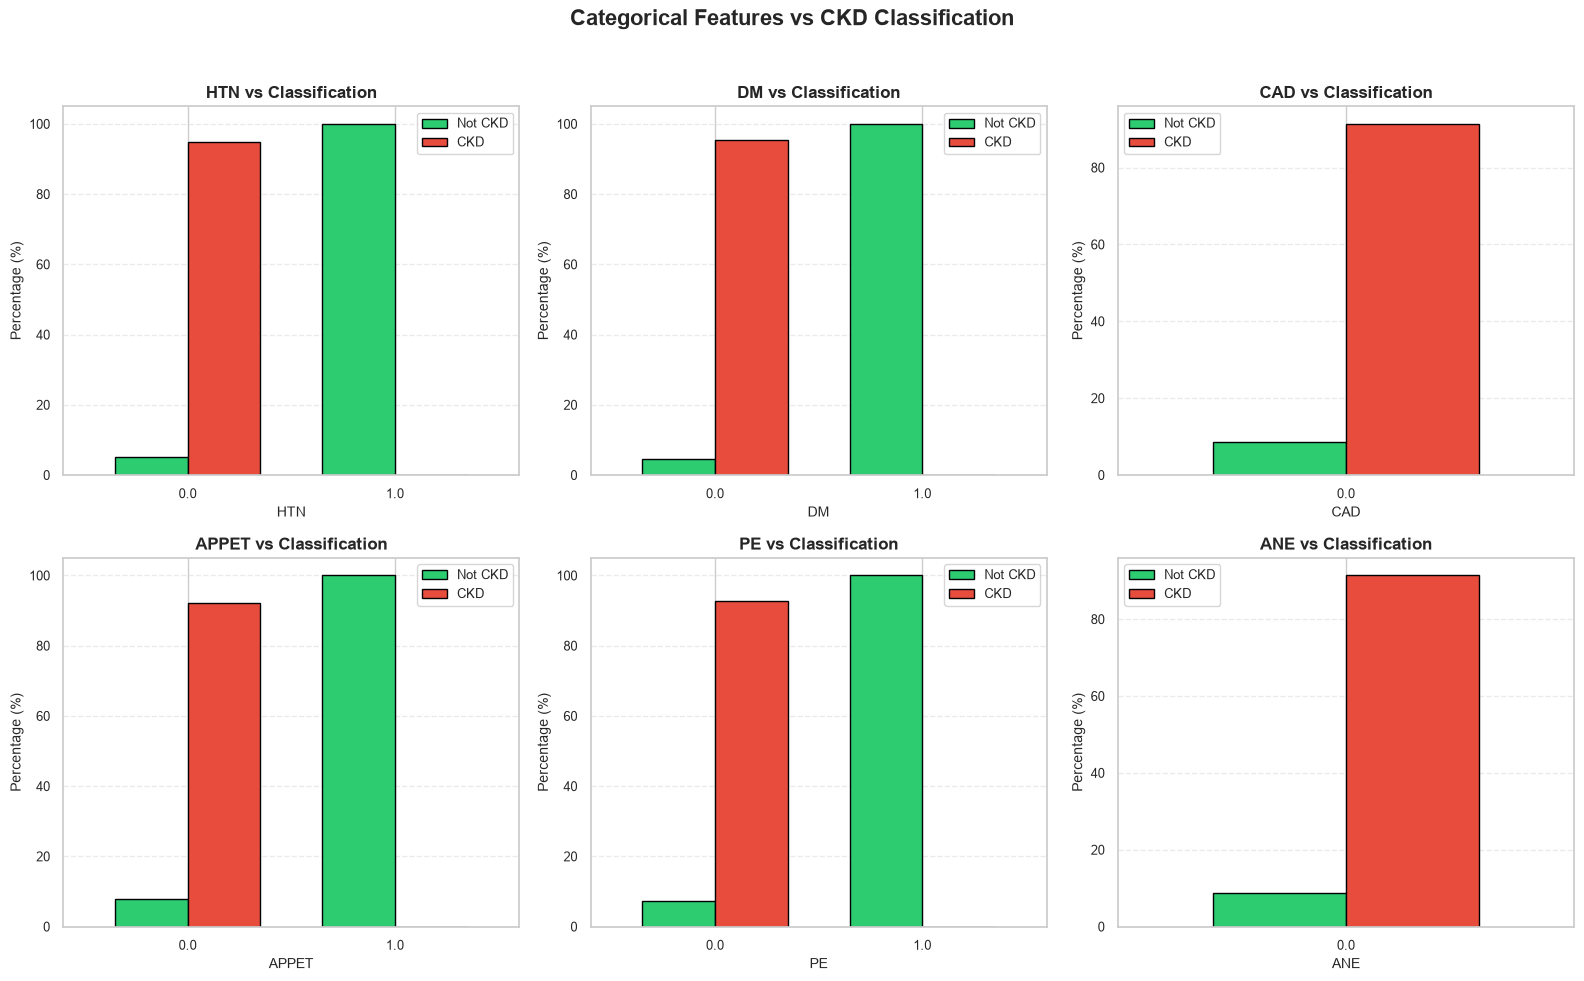


✓ Chart saved to: output/eda_step8_categorical.png

CROSSTAB COUNTS

HTN
------------------------------


classification,0,1,All
htn,,,
0.0,7,127,134
1.0,5,0,5
All,12,127,139



DM
------------------------------


classification,0,1,All
dm,,,
0.0,6,127,133
1.0,6,0,6
All,12,127,139



CAD
------------------------------


...

classification,0,1,All
appet,,,
0.0,11,127,138
1.0,1,0,1
All,12,127,139



PE
------------------------------


classification,0,1,All
pe,,,
0.0,10,127,137
1.0,2,0,2
All,12,127,139



ANE
------------------------------


classification,0,1,All
ane,,,
0.0,12,127,139
All,12,127,139


In [30]:



# Features to analyze
cat_features = ['htn', 'dm', 'cad', 'appet', 'pe', 'ane']

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Colors
colors = ['#2ecc71', '#e74c3c']  # Not CKD, CKD

for ax, col in zip(axes, cat_features):

    # Percentage distribution
    crosstab_pct = (
        pd.crosstab(df_clean[col], df_clean['classification'],
                    normalize='index') * 100
    )

    crosstab_pct.plot(
        kind='bar',
        ax=ax,
        color=colors,
        edgecolor='black',
        width=0.7,
        rot=0
    )

    ax.set_title(f'{col.upper()} vs Classification',
                 fontsize=12,
                 fontweight='bold')

    ax.set_xlabel(col.upper(), fontsize=10)
    ax.set_ylabel('Percentage (%)', fontsize=10)
    ax.legend(['Not CKD', 'CKD'], fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.tick_params(labelsize=9)

# Main title
fig.suptitle(
    'Categorical Features vs CKD Classification',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save figure
plt.savefig(
    'output/eda_step8_categorical.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("\n✓ Chart saved to: output/eda_step8_categorical.png")

# ---------------------------------------------------------
# Crosstab Counts
# ---------------------------------------------------------
print("\n" + "=" * 60)
print("CROSSTAB COUNTS")
print("=" * 60)

for col in cat_features:
    print(f"\n{col.upper()}")
    print("-" * 30)
    display(pd.crosstab(df_clean[col], df_clean['classification'], margins=True))

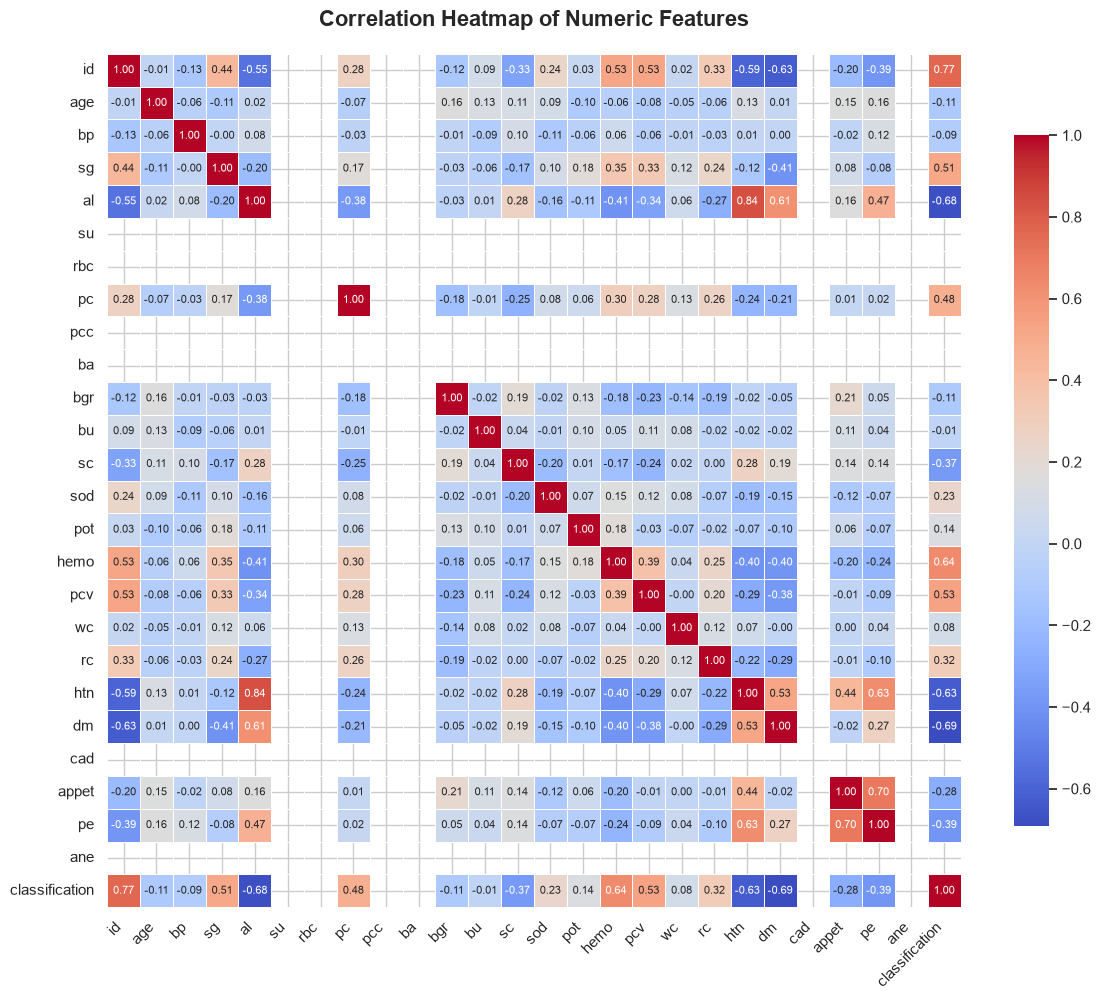


✓ Heatmap saved to: output/eda_step9_correlation_heatmap.png


In [32]:

# Compute correlation matrix for numeric features
corr_matrix = df_clean.select_dtypes(include=['number']).corr()

# Plot heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8}
)

plt.title(
    "Correlation Heatmap of Numeric Features",
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

# Save figure
plt.savefig(
    "output/eda_step9_correlation_heatmap.png",
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("\n✓ Heatmap saved to: output/eda_step9_correlation_heatmap.png")

In [33]:
# Feature engineering
df = df.drop(columns=['id'], errors='ignore')

df['urine_abnormality'] = (
    (df['al'] > 0) |
    (df['su'] > 0) |
    (df['pcc'] > 0) |
    (df['ba'] > 0)
).astype(int)

df['urine_protein_score'] = df[['al', 'su', 'pcc', 'ba']].sum(axis=1)
df['renal_function_avg'] = df[['sc', 'bgr', 'bu']].mean(axis=1)
df['renal_function_load'] = df['sc'] * df['bu']
df['electrolyte_gap'] = (df['sod'] - df['pot']).abs()

df['hemo_pcv_ratio'] = df['hemo'] / df['pcv'].replace({0: np.nan})
df['wbc_rc_ratio'] = df['wc'] / df['rc'].replace({0: np.nan})

df['age_bp_interaction'] = df['age'] * df['bp']
df['comorbidity_flag'] = ((df['htn'] == 1) | (df['dm'] == 1) | (df['cad'] == 1)).astype(int)
df['senior_age_flag'] = (df['age'] >= 60).astype(int)

engineered_cols = [
    'urine_abnormality',
    'urine_protein_score',
    'renal_function_avg',
    'renal_function_load',
    'electrolyte_gap',
    'hemo_pcv_ratio',
    'wbc_rc_ratio',
    'age_bp_interaction',
    'comorbidity_flag',
    'senior_age_flag'
]

print("Added engineered features:")
print(engineered_cols)
df[engineered_cols].head()

Added engineered features:
['urine_abnormality', 'urine_protein_score', 'renal_function_avg', 'renal_function_load', 'electrolyte_gap', 'hemo_pcv_ratio', 'wbc_rc_ratio', 'age_bp_interaction', 'comorbidity_flag', 'senior_age_flag']


,urine_abnormality,urine_protein_score,renal_function_avg,renal_function_load,electrolyte_gap,hemo_pcv_ratio,wbc_rc_ratio,age_bp_interaction,comorbidity_flag,senior_age_flag
5,1,3.0,33.366667,27.5,138.8,2.033333,11.666667,5400.0,1,1
36,1,1.0,40.933333,52.2,129.1,10.300000,2.454545,5320.0,1,1
46,0,0.0,49.733333,28.8,137.8,2.480000,3.666667,3360.0,1,0
62,1,3.0,33.866667,9.0,134.0,5.500000,NaN,900.0,1,0
94,0,0.0,53.533333,105.6,132.5,2.900000,6.000000,4550.0,1,1


In [ ]:
os.makedirs('output', exist_ok=True)
df.to_csv('output/kidney_disease_cleaned.csv', index=False)
print("Saved cleaned dataframe to output/kidney_disease_cleaned.csv")